In [210]:
import duckdb
from pathlib import Path

In [211]:
working_directory = Path.cwd().parent.parent
DATABASE_PATH = working_directory / "data" / "database" / "f1_fantasy.duckdb"

### Meetings Table

In [212]:

def read_raw_meetings_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_meetings_table").df()

    return result

In [213]:
raw_query = read_raw_meetings_table()
raw_query

,meeting_key,meeting_name,meeting_official_name,location,country_key,country_code,country_name,country_flag,circuit_key,circuit_short_name,circuit_type,circuit_info_url,circuit_image,gmt_offset,date_start,date_end,year
0,1140,Pre-Season Testing,FORMULA 1 ARAMCO PRE-SEASON TESTING 2023,Sakhir,36,BRN,Bahrain,https://media.formula1.com/content/dam/fom-web...,63,Sakhir,Permanent,https://api.multiviewer.app/api/v1/circuits/63...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-02-23T07:00:00+00:00,2023-02-25T16:30:00+00:00,2023
1,1141,Bahrain Grand Prix,FORMULA 1 GULF AIR BAHRAIN GRAND PRIX 2023,Sakhir,36,BRN,Bahrain,https://media.formula1.com/content/dam/fom-web...,63,Sakhir,Permanent,https://api.multiviewer.app/api/v1/circuits/63...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-03-03T11:30:00+00:00,2023-03-05T17:00:00+00:00,2023
2,1142,Saudi Arabian Grand Prix,FORMULA 1 STC SAUDI ARABIAN GRAND PRIX 2023,Jeddah,153,KSA,Saudi Arabia,https://media.formula1.com/content/dam/fom-web...,149,Jeddah,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2023-03-17T13:30:00+00:00,2023-03-19T19:00:00+00:00,2023
3,1143,Australian Grand Prix,FORMULA 1 ROLEX AUSTRALIAN GRAND PRIX 2023,Melbourne,5,AUS,Australia,https://media.formula1.com/content/dam/fom-web...,10,Melbourne,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/10...,https://media.formula1.com/content/dam/fom-web...,10:00:00,2023-03-31T02:30:00+00:00,2023-04-02T07:00:00+00:00,2023
4,1207,Azerbaijan Grand Prix,FORMULA 1 AZERBAIJAN GRAND PRIX 2023,Baku,30,AZE,Azerbaijan,https://media.formula1.com/content/dam/fom-web...,144,Baku,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,04:00:00,2023-04-28T09:30:00+00:00,2023-04-30T13:00:00+00:00,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,1298,Mexico City Grand Prix,FORMULA 1 GRAN PREMIO DE LA CIUDAD DE MÉXICO 2026,Mexico City,8,MEX,Mexico,https://media.formula1.com/content/dam/fom-web...,65,Mexico City,Permanent,https://api.multiviewer.app/api/v1/circuits/65...,https://media.formula1.com/content/dam/fom-web...,-06:00:00,2026-10-30T18:30:00+00:00,2026-11-01T22:00:00+00:00,2026
122,1299,São Paulo Grand Prix,FORMULA 1 MSC CRUISES GRANDE PRÊMIO DE SÃO PAU...,São Paulo,10,BRA,Brazil,https://media.formula1.com/content/dam/fom-web...,14,Interlagos,Permanent,https://api.multiviewer.app/api/v1/circuits/14...,https://media.formula1.com/content/dam/fom-web...,-03:00:00,2026-11-06T15:30:00+00:00,2026-11-08T19:00:00+00:00,2026
123,1300,Las Vegas Grand Prix,FORMULA 1 HEINEKEN LAS VEGAS GRAND PRIX 2026,Las Vegas,19,USA,United States,https://media.formula1.com/content/dam/fom-web...,152,Las Vegas,Temporary - Street,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,-08:00:00,2026-11-20T00:30:00+00:00,2026-11-22T06:00:00+00:00,2026
124,1301,Qatar Grand Prix,FORMULA 1 QATAR AIRWAYS QATAR GRAND PRIX 2026,Lusail,149,QAT,Qatar,https://media.formula1.com/content/dam/fom-web...,150,Lusail,Permanent,https://api.multiviewer.app/api/v1/circuits/15...,https://media.formula1.com/content/dam/fom-web...,03:00:00,2026-11-27T13:30:00+00:00,2026-11-29T18:00:00+00:00,2026


In [214]:
raw_query.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   meeting_key            126 non-null    int64 
 1   meeting_name           126 non-null    object
 2   meeting_official_name  126 non-null    object
 3   location               126 non-null    object
 4   country_key            126 non-null    int64 
 5   country_code           126 non-null    object
 6   country_name           126 non-null    object
 7   country_flag           126 non-null    object
 8   circuit_key            126 non-null    int64 
 9   circuit_short_name     126 non-null    object
 10  circuit_type           126 non-null    object
 11  circuit_info_url       126 non-null    object
 12  circuit_image          126 non-null    object
 13  gmt_offset             126 non-null    object
 14  date_start             126 non-null    object
 15  date_end               

In [215]:
def read_staged_meetings_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_meetings_table").df()

    return result

In [216]:
staged_query = read_staged_meetings_table()
staged_query

,meeting_key,meeting_name,country_name,circuit_short_name,circuit_type,date_start,date_end,year
0,1141,Bahrain Grand Prix,Bahrain,Sakhir,Permanent,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,2023
1,1142,Saudi Arabian Grand Prix,Saudi Arabia,Jeddah,Temporary - Street,2023-03-17 09:30:00-04:00,2023-03-17 09:30:00-04:00,2023
2,1143,Australian Grand Prix,Australia,Melbourne,Temporary - Street,2023-03-30 22:30:00-04:00,2023-03-30 22:30:00-04:00,2023
3,1207,Azerbaijan Grand Prix,Azerbaijan,Baku,Temporary - Street,2023-04-28 05:30:00-04:00,2023-04-28 05:30:00-04:00,2023
4,1208,Miami Grand Prix,United States,Miami,Temporary - Street,2023-05-05 14:00:00-04:00,2023-05-05 14:00:00-04:00,2023
...,...,...,...,...,...,...,...,...
89,1298,Mexico City Grand Prix,Mexico,Mexico City,Permanent,2026-10-30 14:30:00-04:00,2026-10-30 14:30:00-04:00,2026
90,1299,São Paulo Grand Prix,Brazil,Interlagos,Permanent,2026-11-06 10:30:00-05:00,2026-11-06 10:30:00-05:00,2026
91,1300,Las Vegas Grand Prix,United States,Las Vegas,Temporary - Street,2026-11-19 19:30:00-05:00,2026-11-19 19:30:00-05:00,2026
92,1301,Qatar Grand Prix,Qatar,Lusail,Permanent,2026-11-27 08:30:00-05:00,2026-11-27 08:30:00-05:00,2026


In [217]:
staged_query.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype                           
---  ------              --------------  -----                           
 0   meeting_key         94 non-null     int64                           
 1   meeting_name        94 non-null     object                          
 2   country_name        94 non-null     object                          
 3   circuit_short_name  94 non-null     object                          
 4   circuit_type        94 non-null     object                          
 5   date_start          94 non-null     datetime64[us, America/New_York]
 6   date_end            94 non-null     datetime64[us, America/New_York]
 7   year                94 non-null     int64                           
dtypes: datetime64[us, America/New_York](2), int64(2), object(4)
memory usage: 6.0+ KB


### Sessions Table

In [218]:
def read_raw_sessions_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_sessions_table WHERE session_key = 9590").df()

    return result

In [219]:
raw_query = read_raw_sessions_table()
raw_query

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,9590,Race,Race,2024-09-01T13:00:00+00:00,2024-09-01T15:00:00+00:00,1244,39,Monza,13,ITA,Italy,Monza,02:00:00,2024


In [220]:
def read_staged_sessions_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_sessions_table").df()

    return result

In [221]:
staged_query = read_raw_sessions_table()
staged_query

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,9590,Race,Race,2024-09-01T13:00:00+00:00,2024-09-01T15:00:00+00:00,1244,39,Monza,13,ITA,Italy,Monza,02:00:00,2024


### Drivers Table

In [222]:
def read_raw_drivers_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_drivers_table").df()

    return result

In [223]:
raw_query = read_raw_drivers_table()

raw_query

,meeting_key,session_key,driver_number,broadcast_name,full_name,name_acronym,team_name,team_colour,first_name,last_name,headshot_url,country_code
0,1141,7767,1,M VERSTAPPEN,Max VERSTAPPEN,VER,Red Bull Racing,3671C6,Max,Verstappen,https://www.formula1.com/content/dam/fom-websi...,NED
1,1141,7767,2,L SARGEANT,Logan SARGEANT,SAR,Williams,37BEDD,Logan,Sargeant,https://www.formula1.com/content/dam/fom-websi...,USA
2,1141,7767,4,L NORRIS,Lando NORRIS,NOR,McLaren,F58020,Lando,Norris,https://www.formula1.com/content/dam/fom-websi...,GBR
3,1141,7767,10,P GASLY,Pierre GASLY,GAS,Alpine,2293D1,Pierre,Gasly,https://www.formula1.com/content/dam/fom-websi...,FRA
4,1141,7767,11,S PEREZ,Sergio PEREZ,PER,Red Bull Racing,3671C6,Sergio,Perez,https://www.formula1.com/content/dam/fom-websi...,MEX
...,...,...,...,...,...,...,...,...,...,...,...,...
9946,1296,11388,55,C SAINZ,Carlos SAINZ,SAI,Williams,1868DB,Carlos,Sainz,https://media.formula1.com/d_driver_fallback_i...,None
9947,1296,11388,63,G RUSSELL,George RUSSELL,RUS,Mercedes,00D7B6,George,Russell,https://media.formula1.com/d_driver_fallback_i...,None
9948,1296,11388,77,V BOTTAS,Valtteri BOTTAS,BOT,Cadillac,909090,Valtteri,Bottas,https://media.formula1.com/d_driver_fallback_i...,None
9949,1296,11388,81,O PIASTRI,Oscar PIASTRI,PIA,McLaren,F47600,Oscar,Piastri,https://media.formula1.com/d_driver_fallback_i...,None


In [224]:
def read_staged_drivers_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_session_drivers_table").df()

    return result

In [225]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:

    result = con.execute("SELECT * FROM staged_race_sessions_table").df()

result

,session_key,session_type,session_name,date_start,date_end,meeting_key
0,9222,Practice,Day 1,2023-02-23 02:00:00-05:00,2023-02-23 02:00:00-05:00,1140
1,7763,Practice,Day 2,2023-02-24 02:00:00-05:00,2023-02-24 02:00:00-05:00,1140
2,7764,Practice,Day 3,2023-02-25 02:00:00-05:00,2023-02-25 02:00:00-05:00,1140
3,7765,Practice,Practice 1,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,1141
4,7766,Practice,Practice 2,2023-03-03 10:00:00-05:00,2023-03-03 10:00:00-05:00,1141
...,...,...,...,...,...,...
485,11429,Practice,Practice 1,2026-12-04 04:30:00-05:00,2026-12-04 04:30:00-05:00,1302
486,11430,Practice,Practice 2,2026-12-04 08:00:00-05:00,2026-12-04 08:00:00-05:00,1302
487,11431,Practice,Practice 3,2026-12-05 05:30:00-05:00,2026-12-05 05:30:00-05:00,1302
488,11432,Qualifying,Qualifying,2026-12-05 09:00:00-05:00,2026-12-05 09:00:00-05:00,1302


In [226]:
staged_drivers = read_staged_drivers_table()
staged_drivers

,meeting_key,session_key,driver_number,full_name,name_acronym,team_name,first_name,last_name
0,1141,7767,1,max verstappen,VER,Red Bull Racing,Max,Verstappen
1,1141,7767,2,logan sargeant,SAR,Williams,Logan,Sargeant
2,1141,7767,4,lando norris,NOR,McLaren,Lando,Norris
3,1141,7767,10,pierre gasly,GAS,Alpine,Pierre,Gasly
4,1141,7767,11,sergio perez,PER,Red Bull Racing,Sergio,Perez
...,...,...,...,...,...,...,...,...
9945,1296,11388,55,carlos sainz,SAI,Williams,Carlos,Sainz
9946,1296,11388,63,george russell,RUS,Mercedes,George,Russell
9947,1296,11388,77,valtteri bottas,BOT,Cadillac,Valtteri,Bottas
9948,1296,11388,81,oscar piastri,PIA,McLaren,Oscar,Piastri


In [227]:
cols= ["meeting_key", "session_key", "full_name"]

duplicates = staged_drivers.duplicated(subset=cols, keep=False)

duplicates

0       False
1       False
2       False
3       False
4       False
        ...  
9945    False
9946    False
9947    False
9948    False
9949    False
Length: 9950, dtype: bool

In [228]:
def read_drivers_dim_table():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_driver").df()

    return result

In [229]:
drivers = read_drivers_dim_table()
drivers

,driver_id,driver_name,name_acronym
0,1,alejandro garcia,GAR
1,2,alexander albon,ALB
2,3,alexander dunne,DUN
3,4,antonio fuoco,FUO
4,5,arthur leclerc,LEL
...,...,...,...
66,67,victor martins,MAR
67,68,woohyun shin,SHI
68,69,yuki tsunoda,TSU
69,70,zak o'sullivan,OSU


### Constructors

In [230]:
def read_raw_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_table").df()

    return result

In [231]:
raw_constructors = read_raw_constructors()
raw_constructors

,constructor_name,year,event_name
0,Alfa Romeo,2023,Azerbaijan Grand Prix
1,Alfa Romeo,2023,Las Vegas Grand Prix
2,Alfa Romeo,2023,São Paulo Grand Prix
3,Alfa Romeo,2023,Hungarian Grand Prix
4,Alfa Romeo,2023,Austrian Grand Prix
...,...,...,...
728,Williams,2023,Spanish Grand Prix
729,Williams,2025,Mexico City Grand Prix
730,Williams,2023,Singapore Grand Prix
731,Williams,2023,Mexico City Grand Prix


In [232]:
def read_staged_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_session_constructors_table").df()

    return result

In [233]:
staged_constructors = read_staged_constructors()
staged_constructors

,year,constructor_name
0,2023,Alfa Romeo
1,2023,AlphaTauri
2,2023,Alpine
3,2023,Aston Martin
4,2023,Ferrari
5,2023,Haas F1 Team
6,2023,McLaren
7,2023,Mercedes
8,2023,Red Bull Racing
9,2023,Williams


In [234]:

def read_warehoused_constructors():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_constructor").df()

    return result

In [235]:
dim_constructors = read_warehoused_constructors()
dim_constructors

,constructor_id,year,constructor_name
0,1,2023,Alfa Romeo
1,2,2023,AlphaTauri
2,3,2023,Alpine
3,4,2024,Alpine
4,5,2025,Alpine
5,6,2026,Alpine
6,7,2023,Aston Martin
7,8,2024,Aston Martin
8,9,2025,Aston Martin
9,10,2026,Aston Martin


### Race

In [236]:
def read_staged_meetings():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM staged_race_meetings_table").df()

    return result

In [237]:
staged_meetings = read_staged_meetings()
staged_meetings

,meeting_key,meeting_name,country_name,circuit_short_name,circuit_type,date_start,date_end,year
0,1141,Bahrain Grand Prix,Bahrain,Sakhir,Permanent,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,2023
1,1142,Saudi Arabian Grand Prix,Saudi Arabia,Jeddah,Temporary - Street,2023-03-17 09:30:00-04:00,2023-03-17 09:30:00-04:00,2023
2,1143,Australian Grand Prix,Australia,Melbourne,Temporary - Street,2023-03-30 22:30:00-04:00,2023-03-30 22:30:00-04:00,2023
3,1207,Azerbaijan Grand Prix,Azerbaijan,Baku,Temporary - Street,2023-04-28 05:30:00-04:00,2023-04-28 05:30:00-04:00,2023
4,1208,Miami Grand Prix,United States,Miami,Temporary - Street,2023-05-05 14:00:00-04:00,2023-05-05 14:00:00-04:00,2023
...,...,...,...,...,...,...,...,...
89,1298,Mexico City Grand Prix,Mexico,Mexico City,Permanent,2026-10-30 14:30:00-04:00,2026-10-30 14:30:00-04:00,2026
90,1299,São Paulo Grand Prix,Brazil,Interlagos,Permanent,2026-11-06 10:30:00-05:00,2026-11-06 10:30:00-05:00,2026
91,1300,Las Vegas Grand Prix,United States,Las Vegas,Temporary - Street,2026-11-19 19:30:00-05:00,2026-11-19 19:30:00-05:00,2026
92,1301,Qatar Grand Prix,Qatar,Lusail,Permanent,2026-11-27 08:30:00-05:00,2026-11-27 08:30:00-05:00,2026


### dim_race

In [238]:
def read_dim_race():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM dim_race").df()

    return result

dim_race = read_dim_race()
dim_race

,race_id,year,race_num,race_name,meeting_key,country_name,circuit_short_name,date_start,date_end,is_sprint_weekend
0,1,2023,1,Bahrain Grand Prix,1141,Bahrain,Sakhir,2023-03-03 06:30:00-05:00,2023-03-03 06:30:00-05:00,False
1,2,2023,2,Saudi Arabian Grand Prix,1142,Saudi Arabia,Jeddah,2023-03-17 09:30:00-04:00,2023-03-17 09:30:00-04:00,False
2,3,2023,3,Australian Grand Prix,1143,Australia,Melbourne,2023-03-30 22:30:00-04:00,2023-03-30 22:30:00-04:00,False
3,4,2023,4,Azerbaijan Grand Prix,1207,Azerbaijan,Baku,2023-04-28 05:30:00-04:00,2023-04-28 05:30:00-04:00,False
4,5,2023,5,Miami Grand Prix,1208,United States,Miami,2023-05-05 14:00:00-04:00,2023-05-05 14:00:00-04:00,False
...,...,...,...,...,...,...,...,...,...,...
89,90,2026,20,Mexico City Grand Prix,1298,Mexico,Mexico City,2026-10-30 14:30:00-04:00,2026-10-30 14:30:00-04:00,False
90,91,2026,21,São Paulo Grand Prix,1299,Brazil,Interlagos,2026-11-06 10:30:00-05:00,2026-11-06 10:30:00-05:00,False
91,92,2026,22,Las Vegas Grand Prix,1300,United States,Las Vegas,2026-11-19 19:30:00-05:00,2026-11-19 19:30:00-05:00,False
92,93,2026,23,Qatar Grand Prix,1301,Qatar,Lusail,2026-11-27 08:30:00-05:00,2026-11-27 08:30:00-05:00,False


### Fantasy tables

In [239]:
def read_raw_driver_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_driver_points_table").df()

    return result


raw_driver_points = read_raw_driver_points()
raw_driver_points
    

,driver,race,points,source_sheet
0,max verstappen,1,35.0,2023DriverPoints
1,sergio perez,1,28.0,2023DriverPoints
2,lewis hamilton,1,19.0,2023DriverPoints
3,lando norris,1,-1.0,2023DriverPoints
4,fernando alonso,1,39.0,2023DriverPoints
...,...,...,...,...
1649,gabriel bortoleto,3,3.0,2026DriverPoints
1650,arvid lindblad,3,1.0,2026DriverPoints
1651,franco colapinto,3,4.0,2026DriverPoints
1652,sergio perez,3,4.0,2026DriverPoints


In [240]:
def read_raw_driver_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_driver_price_table").df()

    return result


raw_driver_price = read_raw_driver_price()
raw_driver_price

,driver,race,price,source_sheet
0,max verstappen,1,26.9,2023DriverPrice
1,lewis hamilton,1,23.7,2023DriverPrice
2,charles leclerc,1,21.2,2023DriverPrice
3,sergio perez,1,18.0,2023DriverPrice
4,george russell,1,18.6,2023DriverPrice
...,...,...,...,...
1671,gabriel bortoleto,4,5.8,2026DriverPrice
1672,arvid lindblad,4,7.6,2026DriverPrice
1673,franco colapinto,4,7.6,2026DriverPrice
1674,sergio perez,4,7.0,2026DriverPrice


In [241]:
def read_raw_constructor_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_price_table").df()

    return result


raw_constructor_price = read_raw_constructor_price()
raw_constructor_price

,constructor,race,price,source_sheet
0,red bull racing,1,27.2,2023ConstructorPrice
1,mercedes,1,25.1,2023ConstructorPrice
2,ferrari,1,22.1,2023ConstructorPrice
3,mclaren,1,9.1,2023ConstructorPrice
4,alpine,1,10.1,2023ConstructorPrice
...,...,...,...,...
739,aston martin,4,8.5,2026ConstructorPrice
740,haas f1 team,4,9.2,2026ConstructorPrice
741,audi,4,5.6,2026ConstructorPrice
742,racing bulls,4,8.1,2026ConstructorPrice


In [242]:
def read_raw_constructor_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM raw_constructor_points_table").df()

    return result


raw_constructor_points = read_raw_constructor_points()
raw_constructor_points

,constructor,race,points,source_sheet
0,red bull racing,1,78,2023ConstructorPoints
1,mercedes,1,45,2023ConstructorPoints
2,ferrari,1,31,2023ConstructorPoints
3,mclaren,1,-16,2023ConstructorPoints
4,aston martin,1,56,2023ConstructorPoints
...,...,...,...,...
728,aston martin,3,-12,2026ConstructorPoints
729,haas f1 team,3,-4,2026ConstructorPoints
730,audi,3,23,2026ConstructorPoints
731,racing bulls,3,18,2026ConstructorPoints


In [243]:
def read_stage_constructor_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_constructor_points_table").df()

    return result


stage_constructor_points = read_stage_constructor_points()
stage_constructor_points

,constructor,race,points,year
0,red bull racing,1,78,2023
1,mercedes,1,45,2023
2,ferrari,1,31,2023
3,mclaren,1,-16,2023
4,aston martin,1,56,2023
...,...,...,...,...
728,aston martin,3,-12,2026
729,haas f1 team,3,-4,2026
730,audi,3,23,2026
731,racing bulls,3,18,2026


In [244]:
def read_stage_constructor_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_constructor_price_table").df()

    return result


stage_constructor_price = read_stage_constructor_price()
stage_constructor_price

,constructor,race,price,year
0,red bull racing,1,27.2,2023
1,mercedes,1,25.1,2023
2,ferrari,1,22.1,2023
3,mclaren,1,9.1,2023
4,alpine,1,10.1,2023
...,...,...,...,...
739,aston martin,4,8.5,2026
740,haas f1 team,4,9.2,2026
741,audi,4,5.6,2026
742,racing bulls,4,8.1,2026


In [245]:
def read_stage_driver_price():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_driver_price_table").df()

    return result


stage_driver_price = read_stage_driver_price()
stage_driver_price

,driver,race,price,year
0,max verstappen,1,26.9,2023
1,lewis hamilton,1,23.7,2023
2,charles leclerc,1,21.2,2023
3,sergio perez,1,18.0,2023
4,george russell,1,18.6,2023
...,...,...,...,...
1482,gabriel bortoleto,4,5.8,2026
1483,arvid lindblad,4,7.6,2026
1484,franco colapinto,4,7.6,2026
1485,sergio perez,4,7.0,2026


In [246]:
def read_stage_driver_points():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("SELECT * FROM stage_driver_points_table").df()

    return result


stage_driver_points = read_stage_driver_points()
stage_driver_points

,driver,race,points,year
0,max verstappen,1,35.0,2023
1,sergio perez,1,28.0,2023
2,lewis hamilton,1,19.0,2023
3,lando norris,1,-1.0,2023
4,fernando alonso,1,39.0,2023
...,...,...,...,...
1460,gabriel bortoleto,3,3.0,2026
1461,arvid lindblad,3,1.0,2026
1462,franco colapinto,3,4.0,2026
1463,sergio perez,3,4.0,2026


### fact_driver_race testing

# SQL build out testing

In [247]:
def fact_driver_race_testing():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            WITH driver_constructor_map AS (
                SELECT DISTINCT
                    meeting_key,
                    full_name,
                    team_name
                FROM staged_session_drivers_table
            )
            SELECT
                r.race_id,
                r.race_name,
                d.driver_id,
                c.constructor_id,
                p.price,
                pts.points AS fantasy_points
            FROM stage_driver_points_table pts
            LEFT JOIN stage_driver_price_table p
                ON pts.year = p.year
               AND pts.race = p.race
               AND pts.driver = p.driver
            LEFT JOIN dim_driver d
                ON pts.driver = d.driver_name
            LEFT JOIN dim_race r
                ON pts.year = r.year
               AND pts.race = r.race_num
            LEFT JOIN driver_constructor_map sd
                ON d.driver_name = sd.full_name
               AND r.meeting_key = sd.meeting_key
            LEFT JOIN dim_constructor c
                ON sd.team_name = c.constructor_name
               AND r.year = c.year
            WHERE r.race_id IS NOT NULL
            ORDER BY race_id
            
        """).df()

    return result

fact_driver_race_test = fact_driver_race_testing()

###### trying to find dups

In [248]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    check = con.execute("""
        SELECT
            year,
            race,
            driver,
            COUNT(*) AS row_count,
            COUNT(DISTINCT points) AS distinct_points
        FROM stage_driver_points_table
        GROUP BY year, race, driver
        HAVING COUNT(*) > 1
        ORDER BY row_count DESC, distinct_points DESC
    """).df()

check.head(20)

,year,race,driver,row_count,distinct_points


In [249]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM stage_driver_points_table
        WHERE year = 2025
          AND race = 3
          AND driver = 'yuki tsunoda'
    """).df()

sample

,driver,race,points,year
0,yuki tsunoda,3,13.0,2025


In [250]:
dups = (
    fact_driver_race_test
    .groupby(["race_id", "driver_id"])
    .size()
    .reset_index(name="row_count")
    .query("row_count > 1")
    .sort_values("row_count", ascending=False)
)

dups.head(10)

,race_id,driver_id,row_count


##### NA count per row

In [251]:
fact_driver_race_test.isna().sum()

race_id           0
race_name         0
driver_id         0
constructor_id    2
price             0
fantasy_points    0
dtype: int64

In [252]:
non_dups = fact_driver_race_test[["race_id", "driver_id"]].drop_duplicates().shape[0]
curr_shape = fact_driver_race_test.shape[0]
print(non_dups, curr_shape)

1445 1445


This should equal 1

In [253]:
fact_driver_race_test.groupby(["race_id", "driver_id"]).size().max()

np.int64(1)

In [254]:
fact_driver_race_test

,race_id,race_name,driver_id,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,61,34,18.0,28.0
1,1,Bahrain Grand Prix,36,23,11.2,-1.0
2,1,Bahrain Grand Prix,55,3,8.1,20.0
3,1,Bahrain Grand Prix,17,7,8.3,39.0
4,1,Bahrain Grand Prix,33,17,6.7,8.0
...,...,...,...,...,...,...
1440,73,Japanese Grand Prix,20,11,6.4,3.0
1441,73,Japanese Grand Prix,10,16,23.4,31.0
1442,73,Japanese Grand Prix,43,37,28.1,13.0
1443,73,Japanese Grand Prix,35,10,6.8,-17.0


In [255]:
fact_driver_race_test.tail(25)

,race_id,race_name,driver_id,constructor_id,price,fantasy_points
1420,72,Chinese Grand Prix,66,12,5.3,3.0
1421,72,Chinese Grand Prix,52,26,25.2,-7.0
1422,72,Chinese Grand Prix,49,20,8.0,34.0
1423,73,Japanese Grand Prix,17,10,8.8,4.0
1424,73,Japanese Grand Prix,15,20,8.5,9.0
1425,73,Japanese Grand Prix,66,12,4.7,2.0
1426,73,Japanese Grand Prix,55,6,12.8,14.0
1427,73,Japanese Grand Prix,34,30,23.8,50.0
1428,73,Japanese Grand Prix,39,33,6.9,10.0
1429,73,Japanese Grand Prix,18,6,7.0,4.0


#### dealing with missing driver_id's 

In [256]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.driver
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        WHERE d.driver_id IS NULL
        ORDER BY pts.driver;
    """).df()

sample

,driver


In [257]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.driver AS fantasy_name
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        WHERE d.driver_id IS NULL;
    """).df()

sample







,fantasy_name


In [258]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM dim_driver
        WHERE name_acronym IN ('BOT', 'GAS', 'ZHO')
    """).df()

sample


,driver_id,driver_name,name_acronym
0,55,pierre gasly,GAS
1,66,valtteri bottas,BOT
2,71,zhou guanyu,ZHO


In [259]:
fact_driver_race_test[
    fact_driver_race_test["driver_id"].isna()
].head(50)

,race_id,race_name,driver_id,constructor_id,price,fantasy_points


#### working through missing pricing

In [260]:

with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.year,
            pts.race,
            pts.driver,
            pts.points
        FROM stage_driver_points_table pts
        LEFT JOIN stage_driver_price_table p
            ON pts.year = p.year
        AND pts.race = p.race
        AND pts.driver = p.driver
        LEFT JOIN dim_race r
            ON pts.year = r.year
        AND pts.race = r.race_num
        WHERE p.price IS NULL
        AND r.race_id IS NOT NULL
        ORDER BY pts.year, pts.race, pts.driver;
    """).df()

sample


,year,race,driver,points


In [261]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT DISTINCT
            pts.year,
            pts.race,
            pts.driver,
            pts.points
        FROM stage_driver_points_table pts
        ORDER BY pts.year, pts.race, pts.driver;
        
        
    """).df()
sample

,year,race,driver,points
0,2023,1,alexander albon,13.0
1,2023,1,carlos sainz,19.0
2,2023,1,charles leclerc,-11.0
3,2023,1,esteban ocon,-17.0
4,2023,1,fernando alonso,39.0
...,...,...,...,...
1460,2026,3,oliver bearman,-14.0
1461,2026,3,oscar piastri,43.0
1462,2026,3,pierre gasly,14.0
1463,2026,3,sergio perez,4.0


In [262]:
race_1_2023_problems = sample[(sample["year"] == 2023) & (sample["race"] == 1)]
race_1_2023_problems

,year,race,driver,points
0,2023,1,alexander albon,13.0
1,2023,1,carlos sainz,19.0
2,2023,1,charles leclerc,-11.0
3,2023,1,esteban ocon,-17.0
4,2023,1,fernando alonso,39.0
5,2023,1,george russell,16.0
6,2023,1,kevin magnussen,8.0
7,2023,1,lance stroll,17.0
8,2023,1,lando norris,-1.0
9,2023,1,lewis hamilton,19.0


In [263]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM raw_driver_points_table
        
        
    """).df()
sample

,driver,race,points,source_sheet
0,max verstappen,1,35.0,2023DriverPoints
1,sergio perez,1,28.0,2023DriverPoints
2,lewis hamilton,1,19.0,2023DriverPoints
3,lando norris,1,-1.0,2023DriverPoints
4,fernando alonso,1,39.0,2023DriverPoints
...,...,...,...,...
1649,gabriel bortoleto,3,3.0,2026DriverPoints
1650,arvid lindblad,3,1.0,2026DriverPoints
1651,franco colapinto,3,4.0,2026DriverPoints
1652,sergio perez,3,4.0,2026DriverPoints


In [264]:
drivers = sample['driver'].unique()
drivers

array(['max verstappen', 'sergio perez', 'lewis hamilton', 'lando norris',
       'fernando alonso', 'carlos sainz', 'george russell',
       'charles leclerc', 'oscar piastri', 'lance stroll', 'pierre gasly',
       'yuki tsunoda', 'daniel ricciardo', 'zhou guanyu',
       'alexander albon', 'esteban ocon', 'liam lawson',
       'kevin magnussen', 'nico hulkenberg', 'nyck de vries',
       'valtteri bottas', 'logan sargeant', 'oliver bearman',
       'jack doohan', 'franco colapinto', 'kimi antonelli',
       'isack hadjar', 'gabriel bortoleto', 'arvid lindblad'],
      dtype=object)

In [265]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT
            year,
            race,
            driver,
            COUNT(*) AS row_count,
            COUNT(DISTINCT price) AS distinct_prices
        FROM stage_driver_price_table
        GROUP BY year, race, driver
        HAVING COUNT(*) > 1
        ORDER BY row_count DESC, distinct_prices DESC;
    """).df()

sample

,year,race,driver,row_count,distinct_prices


### trouble shooting the missing constructor_ids

In [266]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        SELECT *
        FROM dim_driver
    """).df()

sample

,driver_id,driver_name,name_acronym
0,1,alejandro garcia,GAR
1,2,alexander albon,ALB
2,3,alexander dunne,DUN
3,4,antonio fuoco,FUO
4,5,arthur leclerc,LEL
...,...,...,...
66,67,victor martins,MAR
67,68,woohyun shin,SHI
68,69,yuki tsunoda,TSU
69,70,zak o'sullivan,OSU


In [267]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    sample = con.execute("""
        WITH driver_constructor_map AS (
            SELECT DISTINCT
                meeting_key,
                full_name,
                team_name
            FROM staged_session_drivers_table
        )
        SELECT DISTINCT
            r.race_id,
            r.race_name,
            pts.year,
            pts.race,
            pts.driver,
            d.driver_id,
            sd.full_name,
            sd.team_name,
            c.constructor_id
        FROM stage_driver_points_table pts
        LEFT JOIN dim_driver d
            ON pts.driver = d.driver_name
        LEFT JOIN dim_race r
            ON pts.year = r.year
        AND pts.race = r.race_num
        LEFT JOIN driver_constructor_map sd
            ON d.driver_name = sd.full_name
        AND r.meeting_key = sd.meeting_key
        LEFT JOIN dim_constructor c
            ON sd.team_name = c.constructor_name
        AND r.year = c.year
        WHERE c.constructor_id IS NULL
        AND r.race_id IS NOT NULL
        ORDER BY pts.year, pts.race, pts.driver;
    """).df()

sample

,race_id,race_name,year,race,driver,driver_id,full_name,team_name,constructor_id
0,11,Hungarian Grand Prix,2023,11,nyck de vries,48,None,None,<NA>
1,18,United States Grand Prix,2023,18,liam lawson,39,None,None,<NA>


#### reading fact_driver_race from DB

In [268]:
def read_fact_driver_race_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM fact_driver_race
        """).df()
    return result


res = read_fact_driver_race_from_db().tail(20)
res

,race_id,year,race_name,driver_id,constructor_id,price,fantasy_points,driver_finish_position,status
1794,73,2026,Japanese Grand Prix,6,33,7.4,1.0,14.0,Finished
1795,73,2026,Japanese Grand Prix,38,16,22.9,19.0,6.0,Finished
1796,73,2026,Japanese Grand Prix,52,26,24.9,43.0,2.0,Finished
1797,73,2026,Japanese Grand Prix,49,20,8.6,-14.0,22.0,Retired
1798,73,2026,Japanese Grand Prix,26,37,13.9,5.0,12.0,Finished
1799,73,2026,Japanese Grand Prix,61,12,6.4,4.0,17.0,Finished
1800,73,2026,Japanese Grand Prix,2,41,10.8,-1.0,20.0,Lapped
1801,73,2026,Japanese Grand Prix,45,11,5.6,10.0,11.0,Finished
1802,73,2026,Japanese Grand Prix,9,41,12.2,4.0,15.0,Finished
1803,73,2026,Japanese Grand Prix,17,10,8.8,4.0,18.0,Lapped


In [269]:
res.isna().sum()

race_id                   0
year                      0
race_name                 0
driver_id                 0
constructor_id            0
price                     0
fantasy_points            0
driver_finish_position    0
status                    0
dtype: int64

## fact_constructor_race table testing

In [270]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT
            r.race_id,
            r.race_name,
            c.constructor_id,
            p.price,
            pts.points AS fantasy_points,
            
        FROM stage_constructor_points_table pts
        LEFT JOIN stage_constructor_price_table p
            ON pts.year = p.year
            AND pts.race = p.race
            AND pts.constructor = p.constructor
        LEFT JOIN dim_race r
            ON pts.year = r.year
            AND pts.race = r.race_num
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
            AND pts.year = c.year
        WHERE r.race_id IS NOT NULL
    """).df()

res


,race_id,race_name,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,<NA>,27.2,78
1,1,Bahrain Grand Prix,<NA>,25.1,45
2,1,Bahrain Grand Prix,<NA>,22.1,31
3,1,Bahrain Grand Prix,<NA>,9.1,-16
4,1,Bahrain Grand Prix,<NA>,10.1,8
...,...,...,...,...,...
718,73,Japanese Grand Prix,<NA>,9.1,-12
719,73,Japanese Grand Prix,<NA>,8.6,-4
720,73,Japanese Grand Prix,<NA>,5.4,23
721,73,Japanese Grand Prix,<NA>,7.5,18


In [271]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT DISTINCT
            pts.constructor AS fantasy_constructor,
            c.constructor_name AS dim_constructor
        FROM stage_constructor_points_table pts
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
        AND pts.year = c.year
        WHERE c.constructor_id IS NULL
        ORDER BY pts.constructor;"""
    ).df()

res

,fantasy_constructor,dim_constructor
0,alfa romeo,None
1,alphatauri,None
2,alpine,None
3,aston martin,None
4,audi,None
5,cadillac,None
6,ferrari,None
7,haas f1 team,None
8,kick sauber,None
9,mclaren,None


In [272]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
    res = con.execute("""
        SELECT DISTINCT
            pts.constructor AS fantasy_constructor,
            c.constructor_name AS dim_constructor
        FROM stage_constructor_points_table pts
        LEFT JOIN dim_constructor c
            ON pts.constructor = c.constructor_name
        AND pts.year = c.year
        WHERE c.constructor_id IS NULL
        ORDER BY pts.constructor;"""
    ).df()

res

,fantasy_constructor,dim_constructor
0,alfa romeo,None
1,alphatauri,None
2,alpine,None
3,aston martin,None
4,audi,None
5,cadillac,None
6,ferrari,None
7,haas f1 team,None
8,kick sauber,None
9,mclaren,None


In [273]:
def read_fact_constructor_race_from_db():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM fact_constructor_race
        """).df()
    return result


res = read_fact_constructor_race_from_db()
res

,race_id,race_name,constructor_id,price,fantasy_points
0,1,Bahrain Grand Prix,34,27.2,78
1,1,Bahrain Grand Prix,27,25.1,45
2,1,Bahrain Grand Prix,13,22.1,31
3,1,Bahrain Grand Prix,23,9.1,-16
4,1,Bahrain Grand Prix,3,10.1,8
...,...,...,...,...,...
718,73,Japanese Grand Prix,10,9.1,-12
719,73,Japanese Grand Prix,20,8.6,-4
720,73,Japanese Grand Prix,11,5.4,23
721,73,Japanese Grand Prix,33,7.5,18


In [274]:
assert res.groupby(["race_id", "constructor_id"]).size().max() == 1

### placement table

In [283]:
with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM stage_driver_placement
        """).df()

result.head()

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc
0,1,2023,Bahrain Grand Prix,max verstappen,red bull racing,1.0,1,Finished,1.0,0,0,0,0
1,1,2023,Bahrain Grand Prix,sergio perez,red bull racing,2.0,2,Finished,2.0,0,0,0,0
2,1,2023,Bahrain Grand Prix,fernando alonso,aston martin,3.0,3,Finished,5.0,0,0,0,0
3,1,2023,Bahrain Grand Prix,carlos sainz,ferrari,4.0,4,Finished,4.0,0,0,0,0
4,1,2023,Bahrain Grand Prix,lewis hamilton,mercedes,5.0,5,Finished,7.0,0,0,0,0


In [287]:
result[result["finish_position"].isna()]

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc
359,15,2023,Singapore Grand Prix,lance stroll,aston martin,NaN,W,Withdrew,NaN,1,0,0,0


In [142]:
result[result['status'] == "Withdrew"]

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position
359,15,2023,Singapore Grand Prix,lance stroll,aston martin,NaN,W,Withdrew,NaN
477,19,2023,Mexico City Grand Prix,fernando alonso,aston martin,18.0,W,Withdrew,13.0


#### Elo Testing

In [288]:
def read_staged_elo():
    with duckdb.connect(DATABASE_PATH, read_only=True) as con:
        result = con.execute("""
            SELECT * 
            FROM staged_elo_table
        """).df()
    return result


elo_table = read_staged_elo()

In [289]:
elo_table.head()

,race_id,year,race_name,driver,constructor,finish_position,classified_position,status,grid_position,dns,dnf,dsq,nc,elo_position,elo_before,elo_delta,elo_after
0,1,2023,Bahrain Grand Prix,max verstappen,red bull racing,1.0,1,Finished,1.0,False,False,False,False,1.0,1500.0,76.0,1576.0
1,1,2023,Bahrain Grand Prix,sergio perez,red bull racing,2.0,2,Finished,2.0,False,False,False,False,2.0,1500.0,68.0,1568.0
2,1,2023,Bahrain Grand Prix,fernando alonso,aston martin,3.0,3,Finished,5.0,False,False,False,False,3.0,1500.0,60.0,1560.0
3,1,2023,Bahrain Grand Prix,carlos sainz,ferrari,4.0,4,Finished,4.0,False,False,False,False,4.0,1500.0,52.0,1552.0
4,1,2023,Bahrain Grand Prix,lewis hamilton,mercedes,5.0,5,Finished,7.0,False,False,False,False,5.0,1500.0,44.0,1544.0


In [291]:
# clean copy
elo_plot = elo_table.copy()

# sort in race order
elo_plot = elo_plot.sort_values(["year", "race_id", "driver"]).copy()

elo_plot["race_label"] = elo_plot["year"].astype(str) + "-" + elo_plot["race_id"].astype(str)

# continuous race index across all seasons
race_order = (
    elo_plot[["year", "race_id"]]
    .drop_duplicates()
    .sort_values(["year", "race_id"])
    .reset_index(drop=True)
)

race_order["race_index"] = range(1, len(race_order) + 1)

elo_plot = elo_plot.merge(race_order, on=["year", "race_id"], how="left")

In [293]:
import pandas as pd
from pathlib import Path
import importlib


#visualization to check elo rating
import matplotlib.pyplot as plt

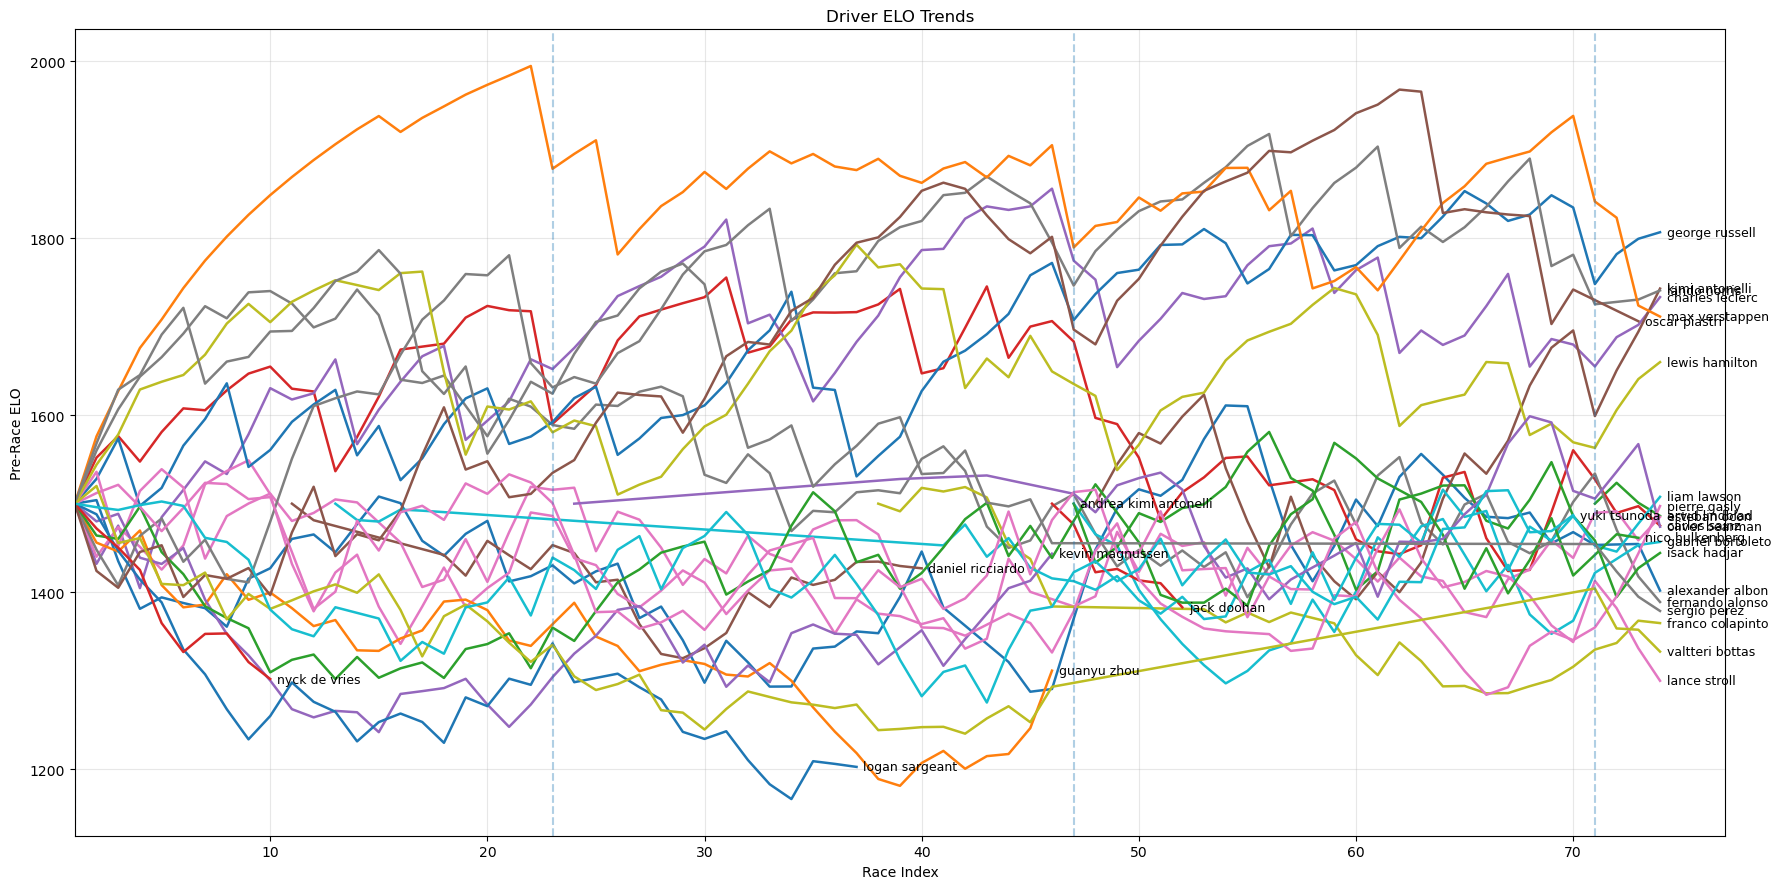

In [294]:
plt.figure(figsize=(18, 9))

# plot each driver line
for driver in sorted(elo_plot["driver"].unique()):
    sub = elo_plot[elo_plot["driver"] == driver].sort_values("race_index")
    plt.plot(sub["race_index"], sub["elo_before"], linewidth=1.8)

    # label at last point
    last_x = sub["race_index"].iloc[-1]
    last_y = sub["elo_before"].iloc[-1]

    plt.text(
        last_x + 0.3,   # push label slightly right of the line
        last_y,
        driver,
        fontsize=9,
        va="center"
    )

# season boundaries
season_starts = (
    race_order.groupby("year", as_index=False)["race_index"]
    .min()
)

for _, row in season_starts.iterrows():
    plt.axvline(row["race_index"], linestyle="--", alpha=0.35)

plt.xlabel("Race Index")
plt.ylabel("Pre-Race ELO")
plt.title(f"Driver ELO Trends")
plt.grid(True, alpha=0.3)

# extend x-axis so labels fit on the right
plt.xlim(elo_plot["race_index"].min(), elo_plot["race_index"].max() + 3)

plt.tight_layout()
plt.show()